# Callbacks

**Goal**: To build a classifier model that predicts the crop disease on images of cassva plants from Uganda. The project uses transfer learning, where a model trained for a task is reused as the starting point for a model on a different task. The project also delves into callbacks, specifically focusing on Learning Rate Scheduling, Checkpointing, and Early Stopping to enhance the training process of the model.

**Objectives**
- Read in data with multiple classes.
- Transform data and prepare it for training.
- Use Transfer Learning to train a classifier model on cassava images.
- Improve training by implementing various callbacks. 
- Prepare a submission for the competition. 

### 1. Setup and Data Preparation

In [17]:
import os 

import matplotlib
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
import PIL
import torch
import torch.nn as nn 
import torch.optim as optim 
import torchinfo
import torchvision
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from torchvision import datasets, models, transforms
from tqdm import tqdm

In [20]:
print("torch version: ", torch.__version__)
print("torchvision version: ", torchvision.__version__)
print("torchinfo version: ", torchinfo.__version__)
print("numpy version: ", np.__version__)
print("matplotlib version: ", matplotlib.__version__)

!python --version

torch version:  2.5.1+cpu
torchvision version:  0.20.1+cpu
torchinfo version:  1.8.0
numpy version:  1.26.3
matplotlib version:  3.8.3
Python 3.12.1


- Check if GPU is available and set the device accordingly:

In [21]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")

Using cpu device.


**Assign data_dir path**

In [22]:
data_dir = os.path.join('data_p2', 'data_undersampled', 'train')

print("Data Directory:", data_dir)

Data Directory: data_p2\data_undersampled\train


**List Class Names**

In [23]:
classes = os.listdir(data_dir)

print("List of classes:", classes)

List of classes: ['cassava-bacterial-blight-cbb', 'cassava-brown-streak-disease-cbsd', 'cassava-green-mottle-cgm', 'cassava-healthy', 'cassava-mosaic-disease-cmd']


**Standardizing the image**
- Convert any greyscale images to RGB format with a custom class.
- Resize the image, so that they are all the same size (224 X 224).
- Convert the image to a Tensor of pixel values.
- Normalize the data. 

In [24]:
class ConvertToRGB(object):
    def __call__(self, img):
        if img.mode != "RGB":
            img = img.convert("RGB")
        return img

**Transformation Pipeline**

In [25]:
transform_normalized = transforms.Compose(
    [
        ConvertToRGB(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean = (0.4326, 0.4953, 0.3120), 
                             std = (0.2178, 0.2214, 0.2091))
    ]
)

print(type(transform_normalized))
print("----------------")
print(transform_normalized)

<class 'torchvision.transforms.transforms.Compose'>
----------------
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.4326, 0.4953, 0.312), std=(0.2178, 0.2214, 0.2091))
)


**Normalize dataset**

In [26]:
normalized_dataset = datasets.ImageFolder(root=data_dir, 
                                         transform=transform_normalized)


print('Length of dataset:', len(normalized_dataset))

Length of dataset: 8180


**Training and Validation Split**

In [27]:
g = torch.Generator()
g.manual_seed(42)

train_dataset, val_dataset = random_split(normalized_dataset, [0.8, 0.2], generator=g)

print("Length of training dataset:", len(train_dataset))
print("Length of validation dataset:", len(val_dataset))

percent_train = np.round(100 * len(train_dataset) / len(normalized_dataset), 2)
percent_val = np.round(100 * len(val_dataset) / len(normalized_dataset), 2)

print(f"Train data is {percent_train}% of full data")
print(f"Validation data is {percent_val}% of full data")

Length of training dataset: 6544
Length of validation dataset: 1636
Train data is 80.0% of full data
Validation data is 20.0% of full data


**Training Data Distribution**

  0%|          | 0/6544 [00:00<?, ?it/s]

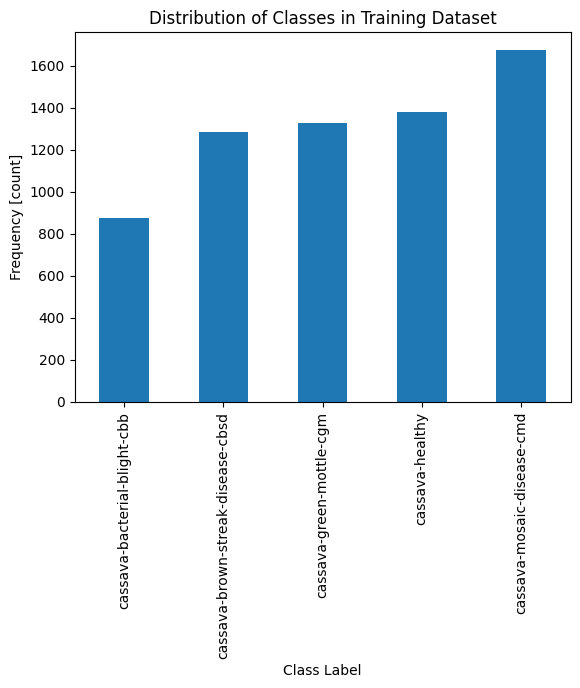

In [29]:
from training import class_counts

train_counts = class_counts(train_dataset)

# Make a bar chart from the function output
train_counts.sort_values().plot(kind='bar')
# Add axis labels and title
plt.xlabel("Class Label")
plt.ylabel("Frequency [count]")
plt.title("Distribution of Classes in Training Dataset");

**Validation Data Distribution**

In [ ]:
val_counts = class_counts(val_dataset)

# Make a bar chart from the function output
val_counts.sort_values().plot(kind='bar')
# Add axis labels and title
plt.xlabel("Class Label")
plt.ylabel("Frequency [count]")
plt.title("Distribution of Classes in Validation Dataset");

  0%|          | 0/1636 [00:00<?, ?it/s]

**Training and Validation Loaders**

In [ ]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(type(train_loader))
print(type(val_loader))